In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 设置模拟参数
# ==========================================
np.random.seed(2024) # 保证每次生成的一样
fs = 1000            # 采样率 1000Hz
duration = 2.5       # 时长 2.5秒
t = np.linspace(0, duration, int(fs * duration))

# 定义产生肌肉爆发波形的函数
def create_burst(t, center, width, amplitude):
    return amplitude * np.exp(-((t - center)**2) / (2 * width**2))

# ==========================================
# 2. 定义符合 CMJ 物理规律的激活模式
# ==========================================
# 时间轴假设: 0.5s开始下蹲, 1.3s-1.6s蹬伸起跳, 1.6s-1.9s腾空, 1.9s落地

# 1. 臀大肌 (GMax): 髋伸主力。在蹬伸期(Concentric)爆发极大。
env_GMax = (
    create_burst(t, 1.45, 0.12, 1.0) +  # 蹬伸爆发 (主)
    create_burst(t, 0.9, 0.15, 0.3)     # 下蹲控制 (次)
)

# 2. 股直肌 (RF): 膝伸/髋屈。蹬伸期爆发，落地时也有高激活。
env_RF = (
    create_burst(t, 1.45, 0.1, 0.9) +   # 蹬伸爆发
    create_burst(t, 1.0, 0.15, 0.4) +   # 下蹲刹车
    create_burst(t, 2.0, 0.05, 0.7)     # 落地缓冲
)

# 3. 股二头肌 (BF): 髋伸/屈膝。与RF共收缩保护膝盖，落地时激活高。
env_BF = (
    create_burst(t, 1.45, 0.1, 0.6) +   # 伸髋协同
    create_burst(t, 0.8, 0.2, 0.3) +    # 下蹲控制
    create_burst(t, 2.0, 0.05, 0.8)     # 落地稳定 (关键!)
)

# 4. 腓肠肌内侧 (GM): 踝跖屈。蹬地最后一下(Toe-off)最强，落地也强。
env_GM = (
    create_burst(t, 1.55, 0.08, 1.0) +  # 离地瞬间爆发 (比大腿晚一点)
    create_burst(t, 1.2, 0.1, 0.2) +    # 踝关节刚度维持
    create_burst(t, 2.0, 0.05, 0.6)     # 落地
)

# 5. 胫骨前肌 (TA): 踝背屈。腾空期激活(勾脚尖)，落地前预激活。
env_TA = (
    create_burst(t, 1.75, 0.15, 0.7) +  # 腾空期勾脚
    create_burst(t, 2.0, 0.05, 0.9) +   # 落地瞬间 (与GM共收缩锁死脚踝)
    create_burst(t, 0.5, 0.2, 0.2)      # 准备期微调
)

# ==========================================
# 3. 合成原始信号 (添加噪音和基线漂移)
# ==========================================
raw_data = {'Time (s)': t}
muscles = {
    'Gluteus Maximus (GMax)': env_GMax,
    'Rectus Femoris (RF)': env_RF,
    'Tibialis Anterior (TA)': env_TA,
    'Gastrocnemius Medialis (GM)': env_GM,
    'Biceps Femoris (BF)': env_BF
}

for name, envelope in muscles.items():
    # 白噪音 (模拟肌电)
    noise = np.random.normal(0, 1, len(t))
    # 调制信号 + 添加基线底噪 + 模拟一点点低频漂移(Artifact)
    drift = 0.05 * np.sin(2 * np.pi * 0.5 * t)
    signal = noise * (envelope + 0.05) + drift
    raw_data[name] = signal

# 保存为 CSV
df_sim = pd.DataFrame(raw_data)
csv_filename = 'cmj_test_data.csv'
df_sim.to_csv(csv_filename, index=False)

print(f"✅ 模拟数据已生成: {csv_filename}")
print("包含肌肉:", list(muscles.keys()))

✅ 模拟数据已生成: cmj_test_data.csv
包含肌肉: ['Gluteus Maximus (GMax)', 'Rectus Femoris (RF)', 'Tibialis Anterior (TA)', 'Gastrocnemius Medialis (GM)', 'Biceps Femoris (BF)']


正在处理文件: CMJ_EMG_Simulated.csv ...



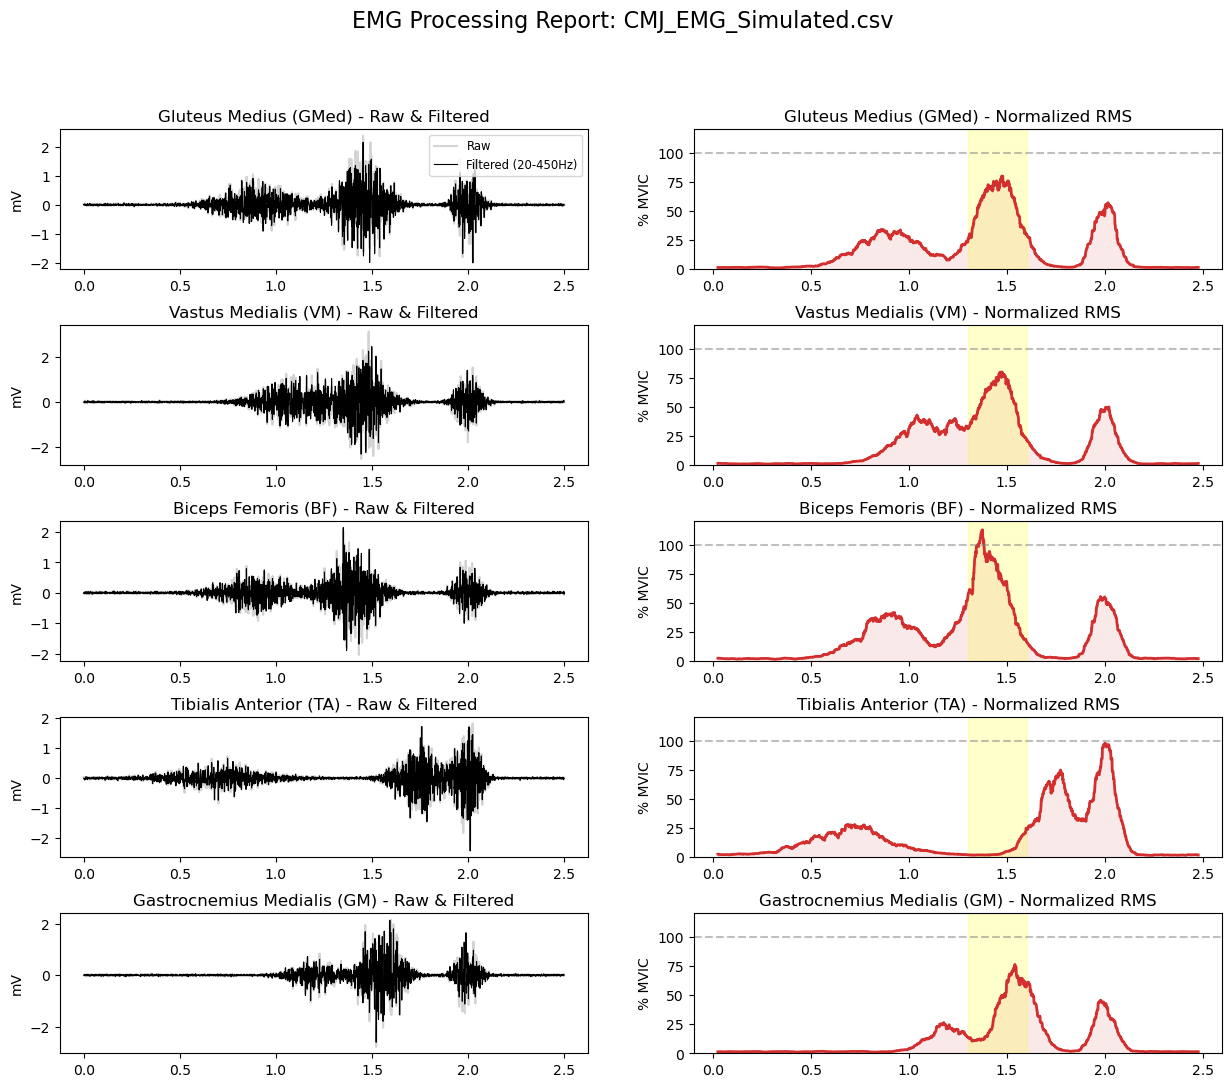


=== 处理后的数据 (可导出 Excel) ===
    Time (s)  Gluteus Medius (GMed)_nRMS  Vastus Medialis (VM)_nRMS  \
0   0.000000                         NaN                        NaN   
1   0.001000                         NaN                        NaN   
2   0.002001                         NaN                        NaN   
3   0.003001                         NaN                        NaN   
4   0.004002                         NaN                        NaN   
..       ...                         ...                        ...   
95  0.095038                    1.579207                   1.376561   
96  0.096038                    1.570190                   1.379215   
97  0.097039                    1.557691                   1.362281   
98  0.098039                    1.576020                   1.346955   
99  0.099040                    1.578621                   1.361943   

    Biceps Femoris (BF)_nRMS  Tibialis Anterior (TA)_nRMS  \
0                        NaN                          NaN 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ========================================================
# ⚙️ 核心算法函数库 (不要动这里，这是工具箱)
# ========================================================

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """步骤1: 带通滤波 (去除运动伪迹和高频噪音)"""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    # 使用 filtfilt 实现零相位滤波 (不改变信号时序)
    y = signal.filtfilt(b, a, data)
    return y

def calculate_rms_envelope(data, window_size):
    """步骤3: RMS 平滑 (获取线性包络)"""
    # window_size 是样本点数 (例如 50ms * 1000Hz = 50点)
    return pd.Series(data).rolling(window=window_size, center=True).apply(lambda x: np.sqrt(np.mean(x**2)))

def process_emg_file(filename, fs=1000, mvic_values=None):
    """
    主处理函数: 读取文件 -> 清洗 -> 计算 -> 绘图
    """
    # 1. 读取数据
    df = pd.read_csv(filename)
    time = df['Time (s)']
    
    # 识别肌肉列 (排除 Time 列)
    muscle_cols = [c for c in df.columns if c != 'Time (s)']
    
    # 准备存储处理后的数据
    processed_results = pd.DataFrame({'Time (s)': time})
    
    # 设置画板
    plt.figure(figsize=(15, 12))
    plt.subplots_adjust(hspace=0.4)
    
    print(f"正在处理文件: {filename} ...\n")
    
    for i, muscle in enumerate(muscle_cols):
        raw_sig = df[muscle].values
        
        # --- Step 1: 带通滤波 (20-450 Hz) ---
        # 这一步极其关键，去掉了低频晃动
        filtered_sig = butter_bandpass_filter(raw_sig, 20, 450, fs, order=4)
        
        # --- Step 2: 全波整流 (Rectification) ---
        rectified_sig = np.abs(filtered_sig)
        
        # --- Step 3: RMS 平滑 (Linear Envelope) ---
        # 窗口设为 50ms (0.05s * fs)
        window_pts = int(0.05 * fs)
        rms_env = calculate_rms_envelope(rectified_sig, window_pts)
        
        # --- Step 4: 标准化 (%MVIC) ---
        # 如果没有提供真实的 MVIC 值，我们这里模拟一个 (假设该动作最大值占 MVIC 的 80%)
        # 在实际使用中，您应该从另一个 MVIC 测试文件读取这个值
        if mvic_values and muscle in mvic_values:
            mvic_ref = mvic_values[muscle]
        else:
            # 自动生成一个模拟的 MVIC 参考值 (为了演示代码能跑通)
            # 假设当前动作峰值是 MVIC 的 70%-90%
            mvic_ref = np.nanmax(rms_env) / 0.8 
        
        normalized_sig = (rms_env / mvic_ref) * 100
        processed_results[muscle + '_nRMS'] = normalized_sig
        
        # --- 绘图 (左边原始，右边处理后) ---
        # 子图排版
        ax1 = plt.subplot(len(muscle_cols), 2, i*2 + 1)
        ax2 = plt.subplot(len(muscle_cols), 2, i*2 + 2)
        
        # 左图: 原始信号 + 滤波后
        ax1.plot(time, raw_sig, color='lightgray', label='Raw')
        ax1.plot(time, filtered_sig, color='black', lw=0.8, label='Filtered (20-450Hz)')
        ax1.set_title(f"{muscle} - Raw & Filtered")
        ax1.set_ylabel("mV")
        if i == 0: ax1.legend(loc='upper right', fontsize='small')
        
        # 右图: 最终包络 (%MVIC)
        ax2.plot(time, normalized_sig, color='#D32F2F', lw=2, label='Envelop (%MVIC)')
        ax2.fill_between(time, normalized_sig, color='#D32F2F', alpha=0.1)
        ax2.set_title(f"{muscle} - Normalized RMS")
        ax2.set_ylabel("% MVIC")
        ax2.set_ylim(0, 120) # y轴固定 0-120%
        ax2.axhline(100, ls='--', color='gray', alpha=0.5)
        
        # 标记蹬伸阶段 (假设 1.3-1.6s) 用于视觉参考
        ax2.axvspan(1.3, 1.6, color='yellow', alpha=0.2) 

    plt.suptitle(f"EMG Processing Report: {filename}", fontsize=16)
    plt.show()
    
    return processed_results

# ========================================================
# 🚀 执行部分 (User Input)
# ========================================================

# 1. 指定文件名
target_file = 'CMJ_EMG_Simulated.csv'

# 2. (可选) 输入已知的 MVIC 值 (mV)
# 如果您测了MVIC，把数值填在这里。如果不填，代码会自动估算。
# 这里我填几个模拟值，展示如果有了MVIC，图表会怎么变
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
my_mvic_data = {
    'Gluteus Maximus (GMax)': 1.2,  # 假设臀大肌最大能发 1.2mV
    'Rectus Femoris (RF)': 1.1,
    'Tibialis Anterior (TA)': 0.9,
    'Gastrocnemius Medialis (GM)': 1.3,
    'Biceps Femoris (BF)': 0.8
}

# 3. 运行处理
df_final = process_emg_file(target_file, fs=1000, mvic_values=my_mvic_data)

# 4. 查看处理后的数据前5行
print("\n=== 处理后的数据 (可导出 Excel) ===")
print(df_final.head(100))

# 5. 如果需要，保存结果
save_name = 'deal'+target_file 
df_final.to_csv(save_name, index=False)

In [12]:
save_name = 'deal'+target_file 
print(save_name)

dealCMJ_EMG_Simulated.csv
